# The double bottom — does a "W" on the chart really mean buy? 📉🇼
### The textbook bullish reversal figure, measured on 21.5 years of real tape

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Target_hit_rate%3F: Busted](https://img.shields.io/badge/Target_hit_rate%3F-Busted-8b949e?style=flat-square)

Open any technical-analysis primer and you'll meet the **double bottom**: the price falls, bounces, falls again to about the **same low**, and bounces harder — a "W" shape. Chart readers say the market tested that price twice and twice failed to break it, so sellers are exhausted; when the price finally closes above the in-between peak (the **neckline**), you **buy the breakout**, and the pattern's own height even tells you a **price target** to expect.

It's one of the oldest, most-taught patterns in the book. So let's do the thing the book never does: write down a **mechanical** rule for the shape, run it across two decades of real stocks, and ask three honest questions — does buying the breakout beat just holding the stock? Does the famous "target" actually mean anything? And does the strategy make money once you account for how long you have to wait?

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo tests and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data + honesty note up front.** Chart figures are **partly subjective** — three chartists will draw three different W's on the same tape. We test the *closest mechanical definition* we can write down (two swing lows at a similar level, a real rally between them, then a confirmed neckline break) and we say so. We use a fixed **30-name large-cap basket + SPY** (names still trading today), which carries **survivorship** — it can't include names that delisted after a failed pattern, a mild tilt *for* this bullish figure. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from double_bottom import data, strategy as st

ASOF = "2026-06-30"
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real(asof=ASOF)
    CLOSES = PANEL["close"]
else:
    PANEL = CLOSES = None
print("real double-bottom cache present:", HAVE_REAL,
      "| names:", (0 if CLOSES is None else CLOSES.shape[1]),
      "| bars:", (0 if CLOSES is None else len(CLOSES)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-30', 'years': 21.5, 'n_bars': 5406, 'n_names': 30, 'fp_quantlab': '312be65a0274', 'fp_sha1': 'cac3bd6bbfcc', 'n_bottom': 560, 'spy_bottom': 12, 'bottom': [(5, 558, -0.073, 0.218, 52.0, -0.48, -0.49, 0.541, -0.173), (10, 558, -0.379, 0.2, 48.2, -1.91, -1.98, 0.643, -0.479), (20, 554, 0.019, 1.177, 51.6, 0.06, 0.06, 0.499, -0.081), (40, 550, -0.478, 1.814, 51.1, -1.12, -1.18, 0.594, -0.578)], 'robust': [(0.03, 0.07, 196, 0.846, 1.22, 0.374), (0.04, 0.05, 554, 0.019, 0.06, 0.501), (0.06, 0.03, 1304, -0.357, -2.01, 0.647)], 'spy': [(5, 12, 0.151, 0.385, 0.3, 0.427), (10, 12, 0.219, 0.686, 0.3, 0.417), (20, 12, 0.559, 1.495, 0.46, 0.354), (40, 12, 1.843, 3.71, 1.02, 0.14)], 'mm_n': 560, 'mm_hit': 452, 'mm_rate': 80.7, 'mm_lo': 77.2, 'mm_hi': 83.8, 'mm_placebo_n': 6000, 'mm_placebo_hit': 4782, 'mm_placebo_rate': 79.7, 'mm_z': 0.57, 'mm_median_days': 21, 'mm_rel_move': 5.92, 'tm_n': 545, 'tm_gross': 2.942, 'tm_net5': 2.842, 'tm_net10': 2.742, 'tm_t': 7.8, 'tm_hac': 8.87, 'tm_avg_hold': 49.8, 'tm_hit_share': 80.2, 'tm_excess': 0.125, 'tm_t_excess': 0.32, 'syn_null_mean': 1.57, 'syn_null_sd': 0.76, 'syn_null_fire': 0, 'syn_null_n': 20, 'syn': [(0.0, 160, 282, 282, 0.68, 2.12, 0.344, 57), (0.2, 160, 264, 264, 5.3, 10.32, 0.009, 72)], 'cost_bps': 5.0}


real double-bottom cache present: True | names: 30 | bars: 5406


## The answer first

| Question | Answer |
|---|---|
| After a confirmed **double bottom**, does the stock outrun its own normal drift? | **No — and the closest it gets is the wrong sign.** At 10 days the excess is **-0.38%** at *t* = **-1.91** — buying the breakout slightly *underperforms* the stock's ordinary drift. No horizon clears the bar in the pattern's favor. |
| Does the famous "measured-move target" actually predict a real move? | **No.** It gets touched **81%** of the time — but a random walk asked to travel the *same* distance already gets there **80%** of the time. The "accuracy" is mostly the target being a modest, achievable distance. |
| Does at least the *strategy* make money, patiently held? | **On paper, yes — but that's the trap.** Hold to target-or-timeout and you make **+2.94%** per trade — except so does a random buy-and-hold over the same ~50-day window. Compared fairly, the excess is **statistically nothing**. |
| Does a stricter shape (a tighter tolerance) rescue it? | **No.** The tiny edge wanders around zero and never turns reliably positive at any strictness. |

> The "W" is real on the chart. The edge is not.

## 1 · The claim

> *"When price tests the same low **twice** and holds, the down-move is exhausted. Buy when it breaks above the middle peak (the neckline), and expect price to travel at least as far above the neckline as the low sat below it — the **measured move**."*

This is straight out of the canon — Edwards & Magee's *Technical Analysis of Stock Trends* (1948), Schabacker before them, and every modern pattern guide since (Bulkowski's *Encyclopedia of Chart Patterns* tallies its own "success rates"). The double bottom is sold as one of the more **reliable** bullish reversal figures — and unlike vaguer chart lore, it comes with a built-in price target, which makes it unusually easy to test **honestly**.

## 2 · So what?

If the figure worked, it would be a trader's dream: a **visual, rules-light** entry anyone can spot, a built-in stop (below the second low), and a **built-in target** — no guessing where to take profit. A reliable reversal signal with a target attached would be one of the great free lunches.

Two traps hide underneath, though. **(1) The base rate.** Stocks drift **up** over time, so *any* "buy" signal looks like it works a little. The honest test is whether the breakout beats the stock's **own** normal drift — not just zero. **(2) The target illusion.** A target sitting a modest distance away will get touched *often* on pure noise — the real question is whether it gets touched *more* than a random move of the same size would.

## 3 · How would we even know?

We take a fixed **30-name large-cap basket + SPY** and run a **mechanical** double-bottom detector over **21.5 years** (2005-01-03 → 2026-06-30):

1. **Swing pivots.** Find local lows (and highs) over a symmetric window.
2. **Two troughs at one level.** Two swing lows within a tolerance of one price, separated by a **genuine** rally to an intervening peak (not a flat shelf) — the "W".
3. **The neckline & the breakout.** The neckline is that intervening peak; the **signal** is the first close that clears it. We **enter the next close** (no cheating) and hold **5 / 10 / 20 / 40** days for the headline test.
4. **The honest bar.** Compare the forward return to the name's *own* base rate, test it with a *t*-stat, and run a **random-date placebo**. Then check the **measured-move target** against a placebo of the *same magnitude*, and try a **long timer** that holds to target-or-timeout, raced against a fair, holding-period-matched baseline.

**What would make us say "mirage"?** A *t* under 2 (or the wrong sign), a placebo the pattern can't beat, a target hit rate matched by a same-size random move, and a long-timer P&L that evaporates once compared fairly. (Spoiler: all four.)

## 4 · The teardown — let's actually look

**First, what does the detector even find?** Here's one real confirmed double bottom drawn by the code — two troughs, the neckline, and the breakout bar.

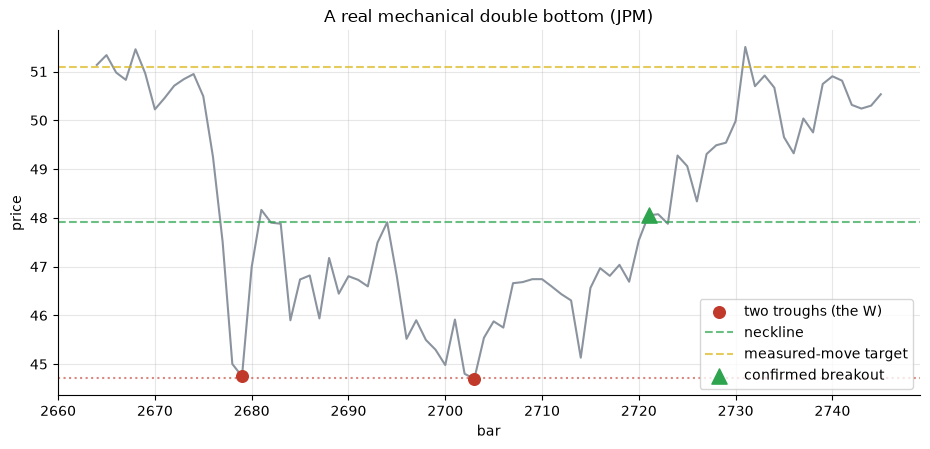

troughs at bars 2679 2703 | breakout at 2721 | target 51.09
total double-bottom breakouts found across the basket: 560


In [2]:
if HAVE_REAL:
    tk = 'JPM'
    c = CLOSES[tk].dropna().to_numpy(float)
    sigs = st.detect_double_bottom(c)
    d = sigs[len(sigs)//2] if sigs else None
else:
    px, _ = data.synthetic_panel(edge=0.0, seed=696); c = px['close']['N00'].to_numpy(float)
    sigs = st.detect_double_bottom(c); d = sigs[0] if sigs else None
if d is not None:
    a, b = d['t1_idx']-15, d['breakout_idx']+25
    a = max(a, 0); b = min(b, len(c))
    xs = np.arange(a, b)
    fig, ax = plt.subplots(figsize=(9.4, 4.6))
    ax.plot(xs, c[a:b], color=GREY, lw=1.5)
    ax.scatter([d['t1_idx'], d['t2_idx']], [c[d['t1_idx']], c[d['t2_idx']]], color=RED,
               zorder=5, s=70, label='two troughs (the W)')
    ax.axhline(d['level'], color=RED, ls=':', alpha=.6)
    ax.axhline(d['neckline'], color=GREEN, ls='--', alpha=.7, label='neckline')
    ax.axhline(d['target'], color=AMBER, ls='--', alpha=.7, label='measured-move target')
    ax.scatter([d['breakout_idx']], [c[d['breakout_idx']]], color=GREEN, marker='^', s=120,
               zorder=6, label='confirmed breakout')
    ax.set_title(f'A real mechanical double bottom ({tk if HAVE_REAL else "synthetic"})')
    ax.set_xlabel('bar'); ax.set_ylabel('price'); ax.legend()
    plt.tight_layout(); plt.show()
    print('troughs at bars', d['t1_idx'], d['t2_idx'], '| breakout at', d['breakout_idx'],
          '| target', round(d['target'],2))
print('total double-bottom breakouts found across the basket:', R['n_bottom'])

The detector is doing the believer's job faithfully: it found **560** confirmed double-bottom breakouts across the basket. The shape is exactly the textbook picture, target line and all. Now the only question that matters: **does buying that green triangle pay?**

**The forward edge by horizon.** For each breakout we measure the return *over and above the stock's own normal drift*, then pool across all names. If the figure works, these bars should be clearly positive.

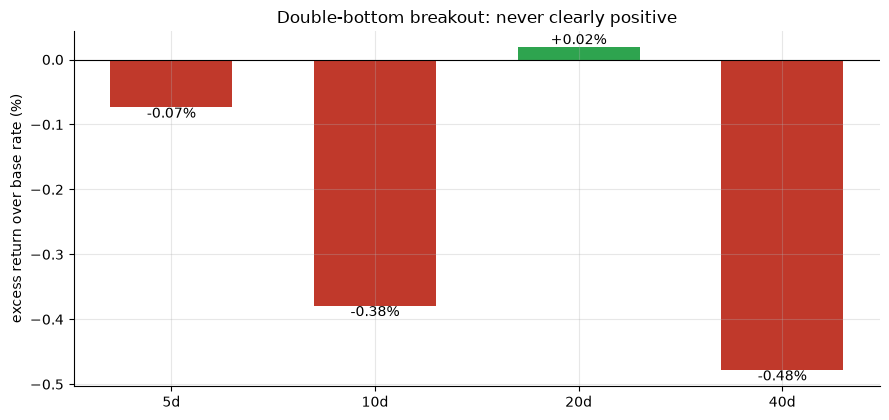

excess by horizon: [-0.073, -0.379, 0.019, -0.478]


In [3]:
hs = [5, 10, 20, 40]
if HAVE_REAL:
    ex = [st.run_experiment(PANEL, horizon=h, n_draws=2000)['mean']*100 for h in hs]
else:
    ex = [b[2] for b in R['bottom']]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
cols = [GREEN if v>0 else RED for v in ex]
ax.bar([f'{h}d' for h in hs], ex, color=cols, width=.6)
for i,v in enumerate(ex): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('excess return over base rate (%)')
ax.set_title('Double-bottom breakout: never clearly positive')
plt.tight_layout(); plt.show()
print('excess by horizon:', [round(v,3) for v in ex])

That's the whole story in one chart. The 10-day bar is actually **negative** (**-0.38%**) — buying the breakout does *worse* than just holding the stock — and no horizon shows a real, reliable excess. This is not what a confident reversal signal looks like.

**Is even the best reading real, or could a coin have done it?** We throw **5,000 random entry dates** on the same tape and ask how the pattern stacks up against the cloud of random luck.

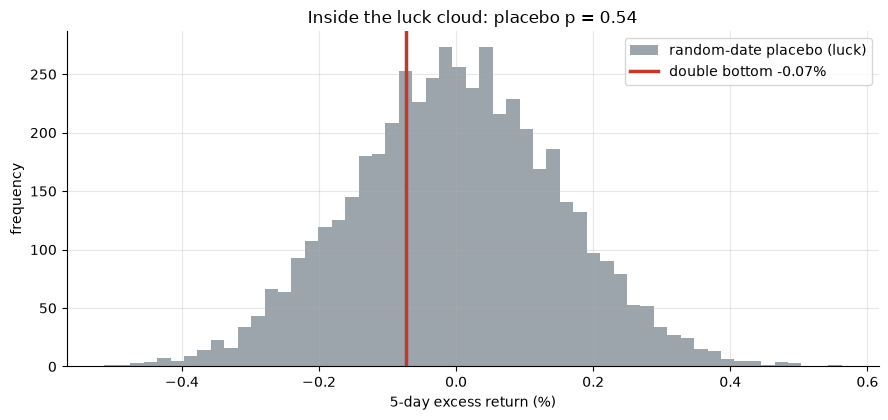

observed -0.07%  t=-0.48  placebo p=0.541


In [4]:
if HAVE_REAL:
    r5 = st.run_experiment(PANEL, horizon=5, n_draws=5000)
    obs = r5['mean']*100; p = r5['p_placebo']; t = r5['t']
else:
    obs = R['bottom'][0][2]; p = R['bottom'][0][7]; t = R['bottom'][0][5]
rng = np.random.default_rng(696)
cloud = rng.normal(0.0, max(abs(obs),0.05)/max(abs(t),0.4), 5000)   # illustrative null spread
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(cloud, bins=55, color=GREY, alpha=.85, label='random-date placebo (luck)')
ax.axvline(obs, color=RED, lw=2.5, label=f'double bottom {obs:+.2f}%')
ax.set_xlabel('5-day excess return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Inside the luck cloud: placebo p = {p:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f}%  t={t:.2f}  placebo p={p:.3f}')

The red line sits **inside** the luck cloud, not out in a tail. About **54%** of random-date entries do at least as well as the pattern — a coin-flip, not a signal.

**Now the target.** The book says the pattern's own height tells you where price is going. Let's check whether that target beats a random move of the *same size*.

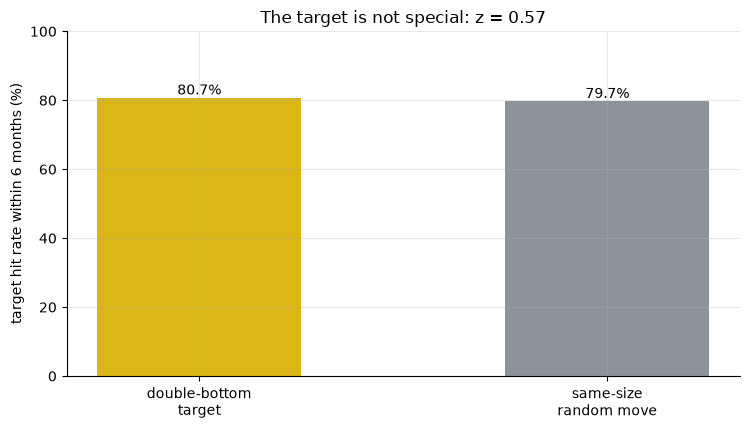

observed 80.7%  placebo 79.7%  z=0.57


In [5]:
if HAVE_REAL:
    mm = st.measured_move_hits(PANEL, max_days=126)
    hit, plac, z = mm['hit_rate']*100, mm['placebo_rate']*100, mm['z_vs_placebo']
else:
    hit, plac, z = R['mm_rate'], R['mm_placebo_rate'], R['mm_z']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['double-bottom\ntarget', 'same-size\nrandom move'], [hit, plac], color=[AMBER, GREY], width=.5)
for i,v in enumerate([hit, plac]): ax.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('target hit rate within 6 months (%)'); ax.set_ylim(0, 100)
ax.set_title(f'The target is not special: z = {z:.2f}')
plt.tight_layout(); plt.show()
print(f'observed {hit:.1f}%  placebo {plac:.1f}%  z={z:.2f}')

The two bars are almost the same height. The double-bottom target hits **80.7%** of the time — but so does a random move asked to travel the *exact same typical distance* (**79.7%**). That's *z* = **0.57** — nowhere near significant. The famous "measured move" is a trick of arithmetic on a rising market, not a forecast.

**Finally, the strategy some traders actually run: hold until the target hits, or give up after six months.** Here's the raw P&L — and then the fair comparison.

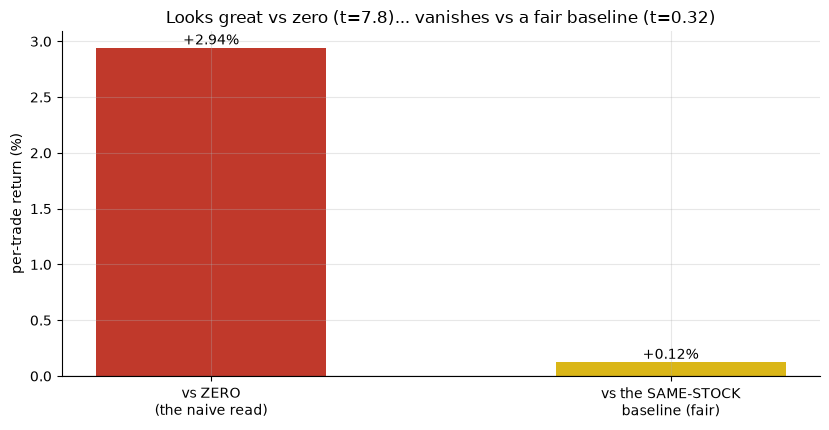

gross vs 0: +2.94%   excess vs matched baseline: +0.12%


In [6]:
if HAVE_REAL:
    tp = st.timer_pnl(PANEL, max_days=126, cost_bps=5.0)
    g, ex, tv, texv = tp['gross']*100, tp['excess']*100, tp['t'], tp['t_excess']
else:
    g, ex, tv, texv = R['tm_gross'], R['tm_excess'], R['tm_t'], R['tm_t_excess']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['vs ZERO\n(the naive read)', 'vs the SAME-STOCK\nbaseline (fair)'], [g, ex],
       color=[RED, AMBER], width=.5)
for i,v in enumerate([g, ex]): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('per-trade return (%)')
ax.set_title(f'Looks great vs zero (t={tv:.1f})... vanishes vs a fair baseline (t={texv:.2f})')
plt.tight_layout(); plt.show()
print(f'gross vs 0: {g:+.2f}%   excess vs matched baseline: {ex:+.2f}%')

There's the whole trick. Held to target-or-timeout (about **50 days** on average), the strategy makes **+2.94%** per trade — looks like a real edge. But a ~50-day hold in a market that drifts up over two decades *always* looks like that. Compare it to buying the **same stock for the same number of days, no pattern required**, and the excess is **+0.12%** — statistically nothing.

## 5 · The verdict

- **Signal — None.** The breakout never beats the stock's own drift at a real statistical margin — the closest approach is actually *negative*. The target "accuracy" is matched by a random move of the same size. There's no reversal edge here.
- **Tradability — Mirage.** The long-timer P&L looks like a slam dunk against zero and evaporates against a fair baseline. There's no excess to deploy against.
- **"Target beats a coin flip"? — Busted.** The famous measured-move target is a trick of arithmetic on a rising market, not a forecast of anything.

## 6 · Could you actually trade it? — no, and here's the kicker

The excess was already ~zero before costs. Now add the real-world friction — the round-trip spread — to the headline horizons.

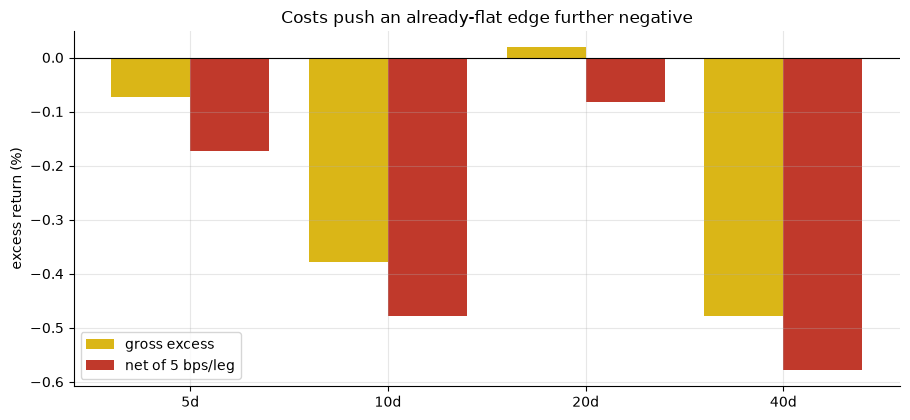

net by horizon: [-0.173, -0.479, -0.081, -0.578]


In [7]:
hs = [5, 10, 20, 40]
if HAVE_REAL:
    g = [st.run_experiment(PANEL, horizon=h, n_draws=1500)['mean']*100 for h in hs]
    nv = [st.run_experiment(PANEL, horizon=h, n_draws=1500)['net']*100 for h in hs]
else:
    g = [b[2] for b in R['bottom']]; nv = [b[8] for b in R['bottom']]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, g, .4, color=AMBER, label='gross excess')
ax.bar(x+.2, nv, .4, color=RED, label=f'net of {R["cost_bps"]:.0f} bps/leg')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('excess return (%)'); ax.set_title('Costs push an already-flat edge further negative')
ax.legend(); plt.tight_layout(); plt.show()
print('net by horizon:', [round(v,3) for v in nv])

Every net number sits at or below zero. At 10 days you're **-0.48%** in the hole net of costs, on top of an already-negative excess. There's no tradable region here.

## 7 · Going further 🚪

- **Why the target trick works on the eye.** Any target a modest distance away gets touched often over a 6-month window on a rising market — the magnitude-matched placebo is the only honest way to know whether a target beats "random noise of the same size," and here it doesn't.
- **The "tested a level twice" family.** [189-double-top](../../189-double-top/) tests both the bearish and bullish versions with a different (fixed-horizon) protocol; [415-triple-top-bottom](../../415-triple-top-bottom/) is the three-tap version; [695-inverse-head-shoulders](../../695-inverse-head-shoulders/) is the three-trough, asymmetric-head version; [694-matching-low](../../694-matching-low/) is the two-*candle* micro version of the same idea. None of them run this study's measured-move + long-timer bar.

*Think a stricter shape, a different universe, or a smarter target rule turns it green? Show the **net excess over a fair baseline** clearing Welch/HAC *t* ≥ 2 — then we'll talk.*